# Forecasting NO₂ (Kwanyar)
Notebook ini berisi:
1. Load data & deteksi kolom tanggal
2. Preprocessing (missing, outlier, freq fixing)
3. Implementasi rumus: SES / DES (Holt) / TES (Holt-Winters additive)
4. Terapkan SES/DES/TES ke dataset NO₂
5. Analisis residual singkat (ACF) dan residual vs waktu
6. PyCaret time series: setup, compare_models, finalize, predict
7. Visualisasi gabungan (manual vs PyCaret)

**File data digunakan**: `NO2_Kwanyar.csv`


#  1.Load data & deteksi kolom tanggal

In [1]:
# Cell 2: Load data & deteksi kolom tanggal
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

path = 'NO2_Kwanyar.csv'   # <-- file lokal Anda
df_raw = pd.read_csv(path)

print("Columns found:", df_raw.columns.tolist())
display(df_raw.head())

# Detect date column from common names; fallback: parse any column with many parseable datetimes
date_cols = ['tanggal','date','Date','DATE','datetime','time','timestamp','waktu','tgl']
found_date_col = None
for c in date_cols:
    if c in df_raw.columns:
        found_date_col = c
        break

if found_date_col is None:
    # try inference
    for c in df_raw.columns:
        try:
            parsed = pd.to_datetime(df_raw[c], errors='coerce')
            if parsed.notna().sum() >= len(df_raw) * 0.6:
                found_date_col = c
                break
        except:
            pass

print("Detected date column:", found_date_col)
if found_date_col is None:
    raise ValueError("Tidak menemukan kolom tanggal otomatis. Pastikan file memiliki kolom tanggal.")

# set index
df_raw[found_date_col] = pd.to_datetime(df_raw[found_date_col], errors='coerce')
df_raw = df_raw.set_index(found_date_col).sort_index()
display(df_raw.head())
print("Index range:", df_raw.index.min(), "->", df_raw.index.max())


FileNotFoundError: [Errno 2] No such file or directory: 'NO2_Kwanyar.csv'

## 2.Preprocessing
Langkah: drop duplicates, handle missing, resample (jika perlu), deteksi frekuensi, outlier handling (IQR capping), optional seasonal decomposition.

In [62]:
# Cell 3: Preprocessing
# 1) Drop duplicated index
df = df_raw[~df_raw.index.duplicated(keep='first')].copy()

# 2) Tentukan kolom NO2
target_col = None
for col in ['NO2','no2','NO_2','no_2','NOx','no_x']:
    if col in df.columns:
        target_col = col
        break
if target_col is None:
    numeric_cols = df.select_dtypes('number').columns.tolist()
    if len(numeric_cols) == 0:
        raise ValueError("Tidak menemukan kolom numerik untuk target NO2.")
    target_col = numeric_cols[0]

print("Target column chosen:", target_col)

# 3) Pastikan index datetime
df.index = pd.to_datetime(df.index)

# 4) Pastikan freq: infer, jika None -> paksa daily ('D')
inferred = pd.infer_freq(df.index)
print("Inferred freq before forcing:", inferred)
if inferred is None:
    # force daily (jika data lebih granular UBah jika diperlukan ke 'H' atau 'M')
    df = df.asfreq('D')
    print("Forced freq = 'D'")
else:
    df = df.asfreq(inferred)
    print("Set freq to inferred:", inferred)
print("Index freq after:", df.index.freq)

# 5) Impute missing: time-interpolate + backfill/ffill
df[target_col] = df[target_col].astype(float)  # pastikan float
df[target_col] = df[target_col].interpolate(method='time')
df[target_col] = df[target_col].fillna(method='bfill').fillna(method='ffill')
print("Missing after imputation:", df[target_col].isna().sum())

# 6) Outlier handling: IQR capping
def iqr_cap(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return s.clip(lower, upper)

df[target_col] = iqr_cap(df[target_col])

# 7) Final working series
series_final = df[target_col].dropna().copy()
series_final.name = 'NO2'
print("Final series length:", len(series_final))
display(series_final.head())
display(series_final.describe())


Target column chosen: NO2
Inferred freq before forcing: None
Forced freq = 'D'
Index freq after: <Day>
Missing after imputation: 0
Final series length: 1022


    Tanggal
2023-01-01    0.000034
2023-01-02    0.000034
2023-01-03    0.000034
2023-01-04    0.000034
2023-01-05    0.000031
Freq: D, Name: NO2, dtype: float64

count    1022.000000
mean        0.000023
std         0.000013
min        -0.000010
25%         0.000014
50%         0.000022
75%         0.000030
max         0.000055
Name: NO2, dtype: float64

#  3.Perhitungan Manual: SES, DES (Holt), dan TES (Holt-Winters additive)

Pada bagian ini kita implementasikan rumus yang ada di makalah:
- **SES**: S_t = α Y_t + (1-α) S_{t-1}
- **DES (Holt)**: level L_t dan trend T_t
  - L_t = α Y_t + (1-α)(L_{t-1} + T_{t-1})
  - T_t = β (L_t - L_{t-1}) + (1-β) T_{t-1}
  - forecast: Ŷ_{t+h} = L_t + h T_t
- **TES (Holt-Winters additive)**: level, trend, seasonal index (untuk m periode)
  - rumus additive sesuai makalah.

Berikut fungsi implementasinya (classical formulas).


In [ ]:
# implementasi fungsi SES, DES, Holt-Winters additive
import numpy as np

def SES(series, alpha, h=30):
    S = [series.iloc[0]]
    fitted = [np.nan]
    for t in range(1, len(series)):
        s_t = alpha * series.iloc[t] + (1 - alpha) * S[-1]
        S.append(s_t)
        fitted.append(S[-2])
    freq = series.index.freq or series.index.inferred_freq or 'D'
    step = pd.tseries.frequencies.to_offset(freq)
    idx = pd.date_range(series.index[-1] + step, periods=h, freq=freq)
    return pd.Series(fitted, index=series.index), pd.Series([S[-1]]*h, index=idx)

def DES(series, alpha, beta, h=30):
    L = [series.iloc[0]]
    if len(series) > 1:
        T = [series.iloc[1] - series.iloc[0]]
    else:
        T = [0.0]
    fitted = [np.nan]
    for t in range(1, len(series)):
        L_t = alpha * series.iloc[t] + (1 - alpha) * (L[-1] + T[-1])
        T_t = beta * (L_t - L[-1]) + (1 - beta) * T[-1]
        L.append(L_t); T.append(T_t)
        fitted.append(L[-2] + T[-2])
    freq = series.index.freq or series.index.inferred_freq or 'D'
    step = pd.tseries.frequencies.to_offset(freq)
    idx = pd.date_range(series.index[-1] + step, periods=h, freq=freq)
    forecast = pd.Series([L[-1] + (i+1) * T[-1] for i in range(h)], index=idx)
    return pd.Series(fitted, index=series.index), forecast

def holt_winters_additive(series, alpha, beta, gamma, m, h=30):
    n = len(series)
    if n < 2*m:
        raise ValueError("Series too short for Holt-Winters with m=%d" % m)
    # initial seasonal indices
    seasonals = {}
    season_averages = []
    n_seasons = int(n / m)
    for j in range(n_seasons):
        season_averages.append(series.iloc[j*m:(j+1)*m].mean())
    for i in range(m):
        sum_of_vals_over_avg = 0.0
        for j in range(n_seasons):
            sum_of_vals_over_avg += series.iloc[j*m + i] - season_averages[j]
        seasonals[i] = sum_of_vals_over_avg / n_seasons
    L = [series.iloc[:m].mean()]
    T = [ (series.iloc[m:2*m].mean() - series.iloc[:m].mean()) / m ]
    fitted = [np.nan] * n
    for i in range(n):
        if i == 0:
            fitted[i] = np.nan
            continue
        val = series.iloc[i]
        s_i = seasonals[i % m]
        L_t = alpha * (val - s_i) + (1 - alpha) * (L[-1] + T[-1])
        T_t = beta * (L_t - L[-1]) + (1 - beta) * T[-1]
        seasonals[i % m] = gamma * (val - L_t) + (1 - gamma) * s_i
        L.append(L_t); T.append(T_t)
        fitted[i] = L[-2] + T[-2] + seasonals[(i-1) % m]
    freq = series.index.freq or series.index.inferred_freq or 'D'
    step = pd.tseries.frequencies.to_offset(freq)
    idx = pd.date_range(series.index[-1] + step, periods=h, freq=freq)
    last_L, last_T = L[-1], T[-1]
    forecast = []
    for i in range(h):
        m_i = (n + i) % m
        forecast.append(last_L + (i+1) * last_T + seasonals[m_i])
    fitted_series = pd.Series(fitted, index=series.index)
    forecast_series = pd.Series(forecast, index=idx)
    return fitted_series, forecast_series


## 4.Terapkan SES/DES/TES dengan parameter contoh dan plot hasil fitting + forecast
Gunakan parameter default alpha/beta/gamma yang bisa Anda ubah.

In [ ]:
# Terapkan SES / DES / TES
alpha = 0.3
beta = 0.1
gamma = 0.1
h = 30

# pilih m (seasonal period) berdasarkan frekuensi; default weekly = 7
freq = pd.infer_freq(series_final.index)
if freq is None:
    m = 7
else:
    if 'M' in freq:
        m = 12
    elif 'D' in freq:
        m = 7
    elif 'H' in freq:
        m = 24
    else:
        m = 7

print("Chosen seasonal period m =", m, "inferred freq:", freq)

ses_fitted, ses_fore = SES(series_final, alpha=alpha, h=h)
des_fitted, des_fore = DES(series_final, alpha=alpha, beta=beta, h=h)

hw_ok = False
try:
    hw_fitted, hw_fore = holt_winters_additive(series_final, alpha=alpha, beta=beta, gamma=gamma, m=m, h=h)
    hw_ok = True
except Exception as e:
    print("Holt-Winters not applied (reason):", e)
    hw_ok = False

# Show head of fitted and forecast
print("SES fitted (head):")
display(ses_fitted.dropna().head())
print("DES fitted (head):")
display(des_fitted.dropna().head())
print("SES forecast (first 5):")
display(ses_fore.head())
print("DES forecast (first 5):")
display(des_fore.head())
if hw_ok:
    print("HW forecast (first 5):")
    display(hw_fore.head())


Chosen seasonal period m = 7 inferred freq: D
SES fitted (head):


    Tanggal
2023-01-02    0.000034
2023-01-03    0.000034
2023-01-04    0.000034
2023-01-05    0.000034
2023-01-06    0.000033
Freq: D, dtype: float64

DES fitted (head):


    Tanggal
2023-01-02    0.000034
2023-01-03    0.000034
2023-01-04    0.000034
2023-01-05    0.000034
2023-01-06    0.000033
Freq: D, dtype: float64

SES forecast (first 5):


2025-10-19    0.000018
2025-10-20    0.000018
2025-10-21    0.000018
2025-10-22    0.000018
2025-10-23    0.000018
Freq: D, dtype: float64

DES forecast (first 5):


2025-10-19    0.000018
2025-10-20    0.000018
2025-10-21    0.000018
2025-10-22    0.000018
2025-10-23    0.000018
Freq: D, dtype: float64

HW forecast (first 5):


2025-10-19    0.000011
2025-10-20    0.000013
2025-10-21    0.000018
2025-10-22    0.000021
2025-10-23    0.000017
Freq: D, dtype: float64

# 5.Plot manual fits + forecasts

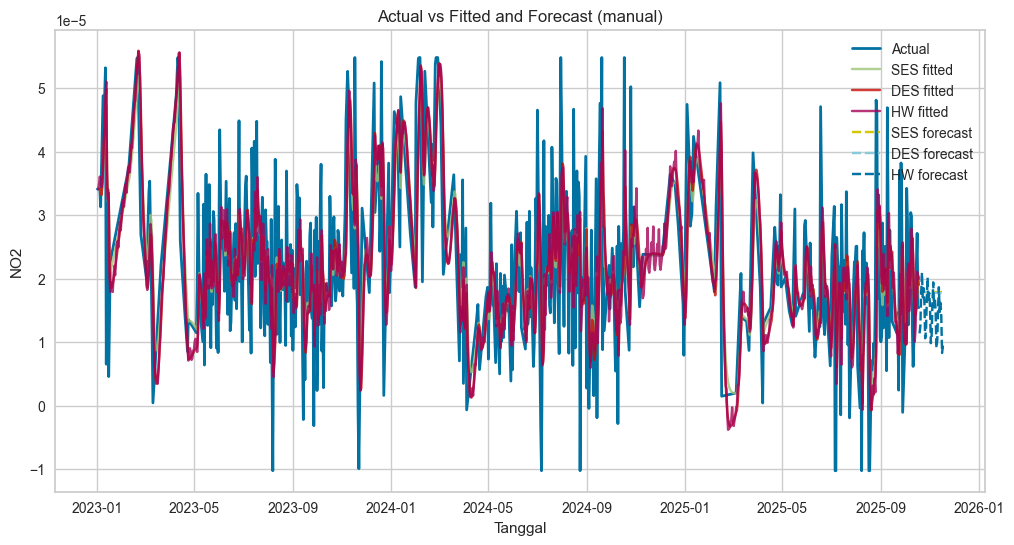

In [65]:
# Cell 7: Plot manual fits + forecasts
plt.figure(figsize=(12,6))
plt.plot(series_final.index, series_final.values, label='Actual', linewidth=2)
plt.plot(ses_fitted.index, ses_fitted.values, label='SES fitted', alpha=0.8)
plt.plot(des_fitted.index, des_fitted.values, label='DES fitted', alpha=0.8)
if hw_ok:
    plt.plot(hw_fitted.index, hw_fitted.values, label='HW fitted', alpha=0.8)
plt.plot(ses_fore.index, ses_fore.values, '--', label='SES forecast')
plt.plot(des_fore.index, des_fore.values, '--', label='DES forecast')
if hw_ok:
    plt.plot(hw_fore.index, hw_fore.values, '--', label='HW forecast')
plt.legend(); plt.title('Actual vs Fitted and Forecast (manual)'); plt.xlabel('Tanggal'); plt.ylabel('NO2')
plt.grid(True); plt.show()


## 6.Analisis residual singkat (ACF) + residual vs waktu

Residual sizes: SES: 1021 DES: 1021


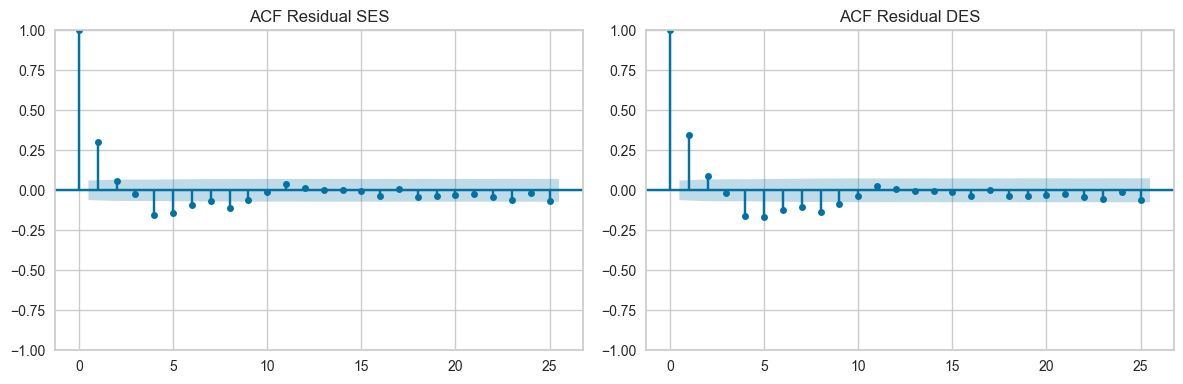

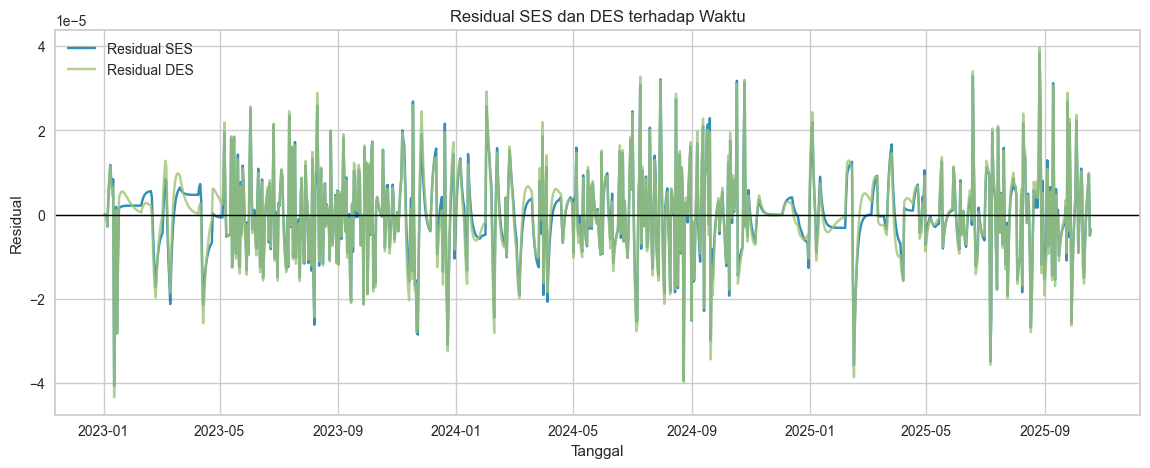

In [ ]:
# Analisis residual (ACF) dan residual vs waktu
from statsmodels.graphics.tsaplots import plot_acf

# Ensure fitted aligned with actual index
ses_fitted = ses_fitted.reindex(series_final.index)
des_fitted = des_fitted.reindex(series_final.index)

res_ses = (series_final - ses_fitted).dropna()
res_des = (series_final - des_fitted).dropna()

print("Residual sizes: SES:", len(res_ses), "DES:", len(res_des))

# ACF plots
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plot_acf(res_ses, lags=25, ax=plt.gca()); plt.title('ACF Residual SES')
plt.subplot(1,2,2)
plot_acf(res_des, lags=25, ax=plt.gca()); plt.title('ACF Residual DES')
plt.tight_layout(); plt.show()

# Residual vs time
plt.figure(figsize=(14,5))
plt.plot(res_ses.index, res_ses.values, label='Residual SES', alpha=0.8)
plt.plot(res_des.index, res_des.values, label='Residual DES', alpha=0.8)
plt.axhline(0, color='black', linewidth=1)
plt.legend(); plt.title('Residual SES dan DES terhadap Waktu'); plt.xlabel('Tanggal'); plt.ylabel('Residual'); plt.grid(True)
plt.show()


# 7.PyCaret setup & compare (disarankan untuk PyCaret 3.3.2)
# Jika pycaret belum terpasang, jalankan pip install terlebih dahulu.

In [67]:
# PyCaret setup & compare (disarankan untuk PyCaret 3.3.2)
# Jika pycaret belum terpasang, jalankan pip install terlebih dahulu.
try:
    from pycaret.time_series import *
except Exception as e:
    raise ImportError("PyCaret tidak ditemukan. Install pycaret 3.x dan dependensinya. Error: " + str(e))

# Prepare df specifically for PyCaret (use series_final)
df_py = series_final.copy()
df_py.index = pd.to_datetime(df_py.index)
df_py = df_py.asfreq('D')  # pastikan freq harian; ubah jika data hourly/monthly

# final checks
print("PyCaret input freq:", df_py.index.freq, "unique values:", df_py.nunique())

# Setup - keep it fast & safe
exp = setup(
    data = df_py,
    fh = 30,
    fold = 2,
    seasonal_period = 7,   # paksa weekly seasonality jika cocok
    n_jobs = -1,
    session_id = 42
)

# Compare models - pilih subset agar cepat; ETS mencakup SES/DES/TES
best = compare_models(include=["ets","arima","theta"])
print("Best model:", best)

final = finalize_model(best)
preds = predict_model(final, fh=30)

print("Preview preds:")
display(preds.head())


PyCaret input freq: <Day> unique values: 1001


,Description,Value
0,session_id,42
1,Target,NO2
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(1022, 1)"
5,Transformed data shape,"(1022, 1)"
6,Transformed train set shape,"(992, 1)"
7,Transformed test set shape,"(30, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
ets,ETS,1.3765,1.3254,0.0000,0.0000,2.6375,1.1644,-1.8293,4.3550
theta,Theta Forecaster,1.7107,1.5322,0.0000,0.0000,3.1987,1.4315,-2.7794,1.8500
arima,ARIMA,1.7550,1.6680,0.0000,0.0000,3.2014,1.1254,-3.4646,3.8750


Best model: AutoETS(seasonal='add', sp=7, trend='add')
Preview preds:


,y_pred
2025-10-19,0.0
2025-10-20,0.0
2025-10-21,0.0
2025-10-22,0.0
2025-10-23,0.0


# 8.Visualisasi gabungan

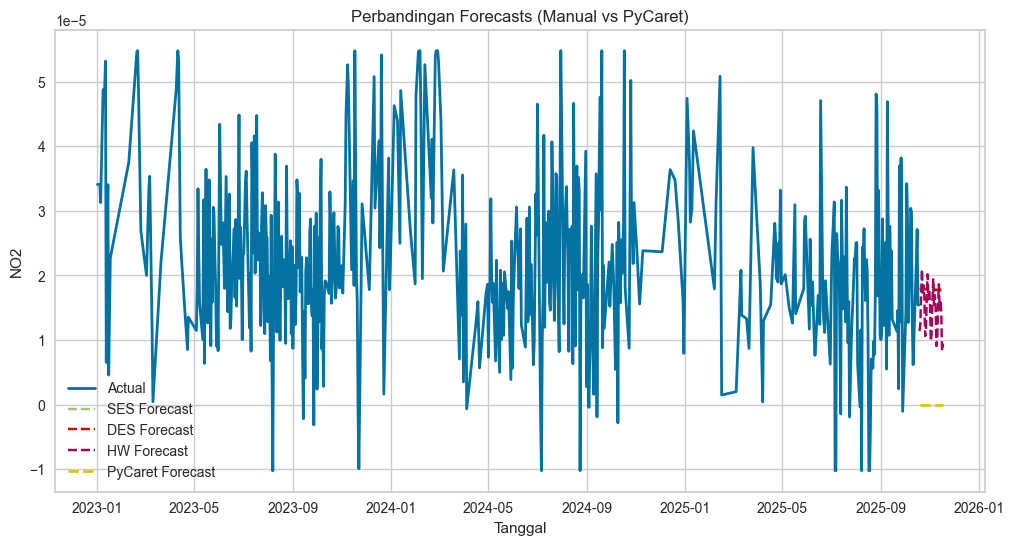

In [ ]:
# Visualisasi gabungan
def to_dt(idx):
    return idx.to_timestamp() if hasattr(idx, 'to_timestamp') else pd.to_datetime(idx)

try:
    if preds is not None:
        pred_col = preds.columns[0]  # otomatis ambil nama kolom prediksi
        actual_idx = to_dt(series_final.index)
        preds_idx = to_dt(preds.index)

        plt.figure(figsize=(12,6))
        plt.plot(actual_idx, series_final.values, label='Actual', linewidth=2)
        # manual forecasts
        plt.plot(to_dt(ses_fore.index), ses_fore.values, '--', label='SES Forecast')
        plt.plot(to_dt(des_fore.index), des_fore.values, '--', label='DES Forecast')
        if hw_ok:
            plt.plot(to_dt(hw_fore.index), hw_fore.values, '--', label='HW Forecast')

        # pycaret forecast
        plt.plot(preds_idx, preds[pred_col], '--', label='PyCaret Forecast', linewidth=2)

        plt.title('Perbandingan Forecasts (Manual vs PyCaret)')
        plt.xlabel('Tanggal'); plt.ylabel('NO2')
        plt.legend(); plt.grid(True); plt.show()
    else:
        print("Variabel 'preds' kosong. PyCaret mungkin gagal atau belum dijalankan.")
except Exception as e:
    print("Visualisasi gabungan gagal:", e)
    # debugging prints
    try:
        print("preds columns:", None if preds is None else preds.columns)
        print("sample preds head:", None if preds is None else preds.head())
    except:
        pass


# 9.Evaluasi singkat (MAE, RMSE) pada split terakhir (hanya contoh)

In [69]:
# Cell 11: Evaluasi singkat (MAE, RMSE) pada split terakhir (hanya contoh)
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Jika ingin evaluasi pada in-sample last h points, kita bisa bandingkan deskriptif:
# contoh: ambil last h actual dan bandingkan dgn ses_fore/des_fore index jika overlap
h = 30
# Jika preds tersedia, hitung MAE/RMSE terhadap preds jika ada actual untuk horizon (biasanya tidak)
if preds is not None:
    pred_col = preds.columns[0]
    # preds.index dapat berisi datetimes setelah akhir series
    # tidak ada actual untuk horizon unless Anda punya holdout; hanya tampilkan preds summary
    print("Preds summary:")
    display(preds.describe())
else:
    print("Preds tidak tersedia — tidak ada metrik forecast out-of-sample yang bisa dihitung.")


Preds summary:


,y_pred
count,30.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0
